In [12]:
# Module 1: Imports and shared settings.
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bayesflow as bf

sys.path.insert(0, "/Users/yimingzang/Documents/thesis/benchmark2")

from benchmark.examples.gaussian.analysis import summry_diagnostic as sd
from benchmark.examples.gaussian.analytic.analytic import GaussianAnalytical
from benchmark.examples.gaussian.npe.estimation import MarginalLikelihoodEstimator

RNG = np.random.default_rng(2026)

num_dims = 20
num_obs = 50
mu_prior_std = 1
likelihood_std = 1

m1_prior_mean = 0.0
m2_prior_mean = 0.5

prior_means = [0, 0.1,0.2,0.5, 1, 3]
num_datasets = 50
num_logml_samples = 1000

m1_path = Path("/Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian/networks/m1_s_20d_50n.keras")
m2_path = Path("/Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian/networks/m2_s_20d_50n.keras")


In [13]:
from tqdm.auto import tqdm as original_tqdm
import bayesflow.approximators.helpers.samplers as bf_samplers
import bayesflow.approximators.helpers.conditions as bf_conditions

def quiet_tqdm(*args, **kwargs):
    kwargs["disable"] = True
    return original_tqdm(*args, **kwargs)

bf_samplers.tqdm = quiet_tqdm
bf_conditions.tqdm = quiet_tqdm


In [14]:
# Module 2: Define simulators and load both trained networks.
def prior_m1():
    mu = RNG.normal(loc=m1_prior_mean, scale=mu_prior_std, size=num_dims)
    return dict(mu=mu)
def prior_m2():
    mu = RNG.normal(loc=m2_prior_mean, scale=mu_prior_std, size=num_dims)
    return dict(mu=mu)
def likelihood(mu):
    x =RNG.normal(loc=mu, scale=likelihood_std, size=(num_obs, num_dims))
    return dict(x=x)

def make_prior_mean(m):
    return lambda: dict(mu=RNG.normal(loc=m, scale=mu_prior_std, size=num_dims))


sim_m1 = bf.make_simulator([prior_m1, likelihood])
sim_m2 = bf.make_simulator([prior_m2, likelihood])

app1 = sd.load_approximator(m1_path)
app2 = sd.load_approximator(m2_path)


(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Reference distribution of summary-space Mahalanobis distance'}, xlabel='Mahalanobis distance $d_M$', ylabel='Density'>)

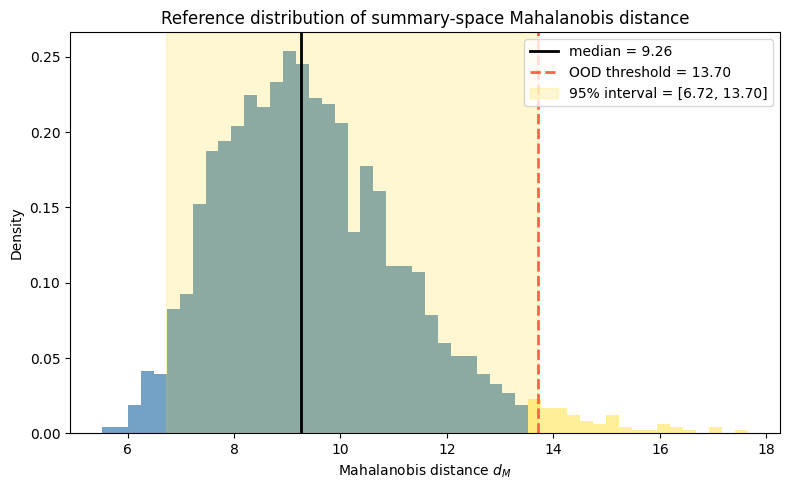

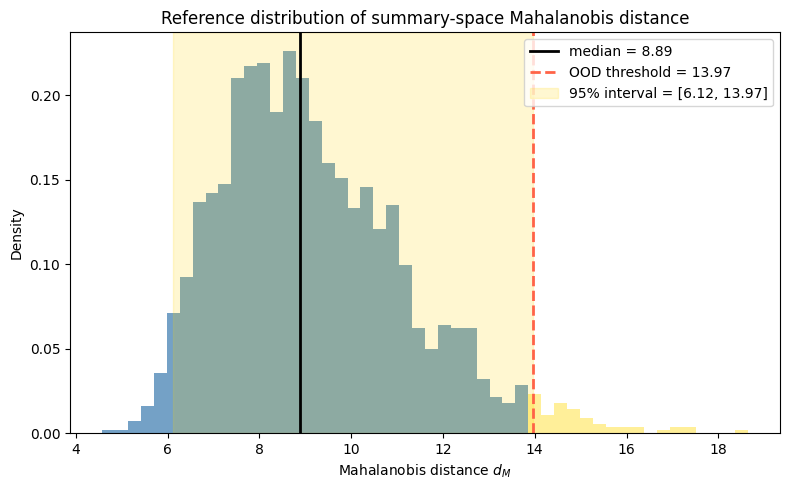

In [15]:
# Module 3: Build each network's own reference d_M distribution.
ref1 = sd.fit_reference(app1, sim_m1, n_ref=2000)
ref2 = sd.fit_reference(app2, sim_m2, n_ref=2000)

sd.plot_reference(ref1)
sd.plot_reference(ref2)


In [16]:
# Module 4: Generate one shared observation set and compute d1, d2, logBF12 error.
rows = []

for pm in prior_means:
    sim_pm = bf.make_simulator([make_prior_mean(pm), likelihood])
    sims = sim_pm.sample(num_datasets)
    x_batch = sims["x"]

    d1 = sd.mahalanobis_from_obs(app1, x_batch, ref1)
    d2 = sd.mahalanobis_from_obs(app2, x_batch, ref2)

    post1 = app1.sample(conditions={"x": x_batch}, num_samples=num_logml_samples)["mu"]
    post2 = app2.sample(conditions={"x": x_batch}, num_samples=num_logml_samples)["mu"]

    for i, x_i in enumerate(x_batch):
        gold_logml_1 = GaussianAnalytical(x_i, m1_prior_mean, mu_prior_std, num_dims, num_obs, num_logml_samples, likelihood_std, RNG).log_marginal_analytical()
        gold_logml_2 = GaussianAnalytical(x_i, m2_prior_mean, mu_prior_std, num_dims, num_obs, num_logml_samples, likelihood_std, RNG).log_marginal_analytical()

        npe_logml_1 = MarginalLikelihoodEstimator(app1, post1[i], x_i, m1_prior_mean, mu_prior_std, num_dims, likelihood_std, rng=RNG).log_marginal_npe()
        npe_logml_2 = MarginalLikelihoodEstimator(app2, post2[i], x_i, m2_prior_mean, mu_prior_std, num_dims, likelihood_std, rng=RNG).log_marginal_npe()

        gold_bf12 = gold_logml_1 - gold_logml_2
        npe_bf12 = npe_logml_1 - npe_logml_2


        rows.append(
            {
                "prior_mean": pm,
                "id": i,
                "d1": d1[i],
                "d2": d2[i],
                "d_max": max(d1[i], d2[i]),
                "d_mean": 0.5 * (d1[i] + d2[i]),
                "d_diff": abs(d1[i] - d2[i]),
                "gold_logBF12": gold_bf12,
                "npe_logBF12": npe_bf12,
                "logBF12_error": npe_bf12 - gold_bf12,
                "abs_logBF12_error": abs(npe_bf12 - gold_bf12),
                "ood_m1": d1[i] > ref1["threshold"],
                "ood_m2": d2[i] > ref2["threshold"],
                "ood_any": (d1[i] > ref1["threshold"]) or (d2[i] > ref2["threshold"]),
            }
        )

bf12_df = pd.DataFrame(rows)
display(bf12_df.head())


,prior_mean,id,d1,d2,d_max,d_mean,d_diff,gold_logBF12,npe_logBF12,logBF12_error,abs_logBF12_error,ood_m1,ood_m2,ood_any
0,0.0,0,11.123100,13.948810,13.948810,12.535955,2.825710,7.031007,6.959569,-0.071437,0.071437,False,False,False
1,0.0,1,10.218566,9.526392,10.218566,9.872479,0.692175,1.254437,1.259993,0.005556,0.005556,False,False,False
2,0.0,2,7.763216,7.093319,7.763216,7.428267,0.669897,1.264150,1.265135,0.000985,0.000985,False,False,False
3,0.0,3,9.393213,12.282343,12.282343,10.837778,2.889129,3.925421,3.920926,-0.004494,0.004494,False,False,False
4,0.0,4,8.265804,12.290015,12.290015,10.277910,4.024210,8.011516,8.074080,0.062564,0.062564,False,False,False


In [17]:
# Module 5: Summarize by generating prior mean.
bf12_summary = (
    bf12_df.groupby("prior_mean")
    .agg(
        median_d_max=("d_max", "median"), # the median of the max d_M across the two models
        q025_d_max=("d_max", lambda x: np.percentile(x, 2.5)),
        q975_d_max=("d_max", lambda x: np.percentile(x, 97.5)),
        ood_any_rate=("ood_any", "mean"), # the rate of being OOD by at least one model
        median_logBF12_error=("logBF12_error", "median"),
        q025_logBF12_error=("logBF12_error", lambda x: np.percentile(x, 2.5)),
        q975_logBF12_error=("logBF12_error", lambda x: np.percentile(x, 97.5)),
    )
    .reset_index()
)

display(bf12_summary)


,prior_mean,median_d_max,q025_d_max,q975_d_max,ood_any_rate,median_logBF12_error,q025_logBF12_error,q975_logBF12_error
0,0.0,11.133301,7.214206,15.643798,0.12,0.005867,-0.073747,0.083769
1,0.1,11.084468,7.425599,17.094436,0.14,0.000362,-0.102925,0.106346
2,0.2,10.017727,6.871274,16.584439,0.10,0.004589,-0.120556,0.080215
3,0.5,10.154908,7.534589,16.691219,0.10,-0.003524,-0.088982,0.063335
4,1.0,14.569790,10.466421,22.014352,0.60,-0.028532,-0.311645,0.176585
5,3.0,39.684941,31.707286,51.793989,1.00,-27.218331,-89.868840,-2.624212


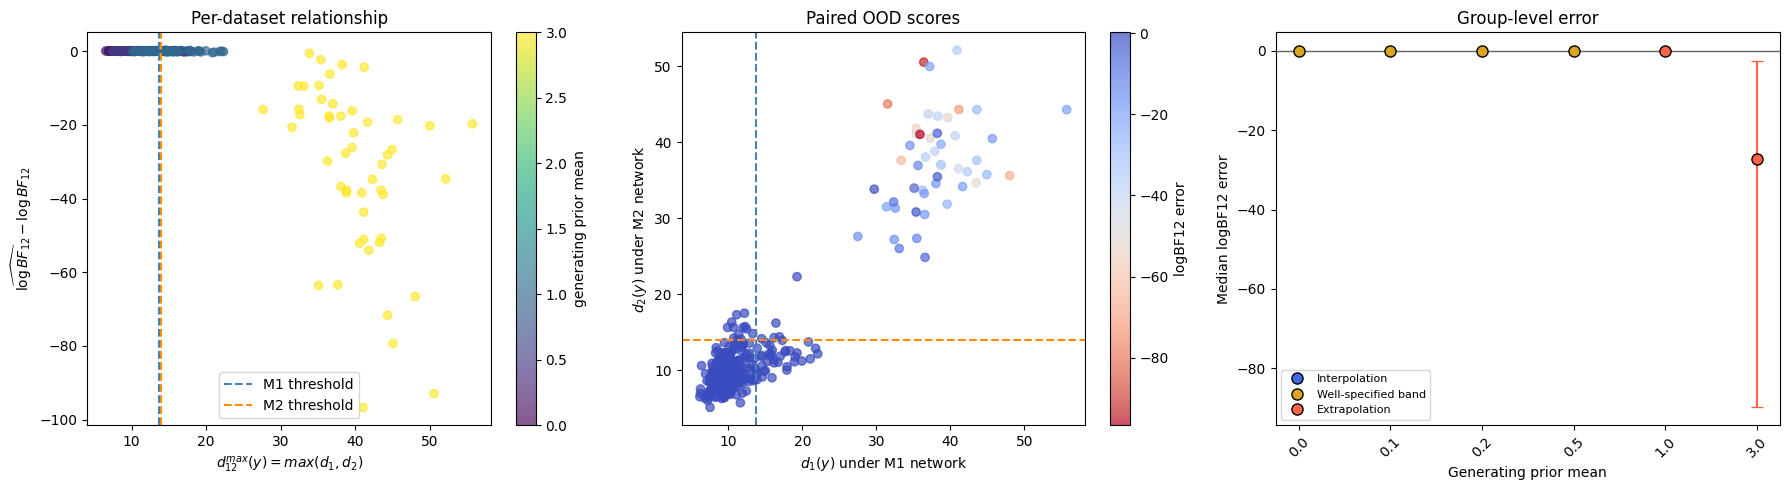

In [18]:
# Module 6: Plot paired OOD scores vs absolute logBF12 error.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sc = axes[0].scatter(bf12_df["d_max"], bf12_df["logBF12_error"], c=bf12_df["prior_mean"], cmap="viridis", alpha=0.65)
axes[0].axvline(ref1["threshold"], color="steelblue", ls="--", label="M1 threshold")
axes[0].axvline(ref2["threshold"], color="darkorange", ls="--", label="M2 threshold")
axes[0].set_xlabel(r"$d_{12}^{max}(y)=max(d_1,d_2)$")
axes[0].set_ylabel(r"$\widehat{\log BF}_{12} - \log BF_{12}$")
axes[0].set_title("Per-dataset relationship")
axes[0].legend()
fig.colorbar(sc, ax=axes[0], label="generating prior mean")

er=axes[1].scatter(bf12_df["d1"], bf12_df["d2"], c=bf12_df["logBF12_error"], cmap="coolwarm_r", alpha=0.70)
axes[1].axvline(ref1["threshold"], color="steelblue", ls="--")
axes[1].axhline(ref2["threshold"], color="darkorange", ls="--")
axes[1].set_xlabel(r"$d_1(y)$ under M1 network")
axes[1].set_ylabel(r"$d_2(y)$ under M2 network")
axes[1].set_title("Paired OOD scores")
fig.colorbar(er, ax=axes[1], label="logBF12 error")

# Group-level error colored by OOD region.
x = np.arange(len(bf12_summary))

region_colors = []
for d in bf12_summary["median_d_max"]:
    if d < min(ref1["dm_low"], ref2["dm_low"]):
        region_colors.append("royalblue")   # interpolation
    elif d <= max(ref1["threshold"], ref2["threshold"]):
        region_colors.append("goldenrod")   # well-specified band
    else:
        region_colors.append("tomato")      # extrapolation (at least one model)

axes[2].axhline(0, color="black", lw=1, alpha=0.6)

for i, row in bf12_summary.iterrows():
    axes[2].errorbar(
        i,
        row["median_logBF12_error"],
        yerr=[
            [row["median_logBF12_error"] - row["q025_logBF12_error"]],
            [row["q975_logBF12_error"] - row["median_logBF12_error"]],
        ],
        fmt="o",
        ms=8,
        capsize=4,
        color=region_colors[i],
        markeredgecolor="black",
    )

axes[2].set_xticks(x)
axes[2].set_xticklabels([str(v) for v in bf12_summary["prior_mean"]], rotation=45)
axes[2].set_xlabel("Generating prior mean")
axes[2].set_ylabel("Median logBF12 error")
axes[2].set_title("Group-level error")

from matplotlib.lines import Line2D
axes[2].legend(
    handles=[
        Line2D([0], [0], marker="o", color="w", label="Interpolation", markerfacecolor="royalblue", markeredgecolor="black", markersize=8),
        Line2D([0], [0], marker="o", color="w", label="Well-specified band", markerfacecolor="goldenrod", markeredgecolor="black", markersize=8),
        Line2D([0], [0], marker="o", color="w", label="Extrapolation", markerfacecolor="tomato", markeredgecolor="black", markersize=8),
    ],
    fontsize=8,
)
plt.tight_layout()
plt.show()


In [19]:
# Module 7: Convert logBF12 to two-model PMP using softmax function.
from benchmark.examples.gaussian.direct.calculator import softmax_stable

bf12_df["gold_pmp_m1"] = [softmax_stable(np.array([v, 0.0]))[0] for v in bf12_df["gold_logBF12"]]
bf12_df["npe_pmp_m1"] = [softmax_stable(np.array([v, 0.0]))[0] for v in bf12_df["npe_logBF12"]]
bf12_df["pmp_m1_error"] = bf12_df["npe_pmp_m1"] - bf12_df["gold_pmp_m1"]
bf12_df["abs_pmp_m1_error"] = bf12_df["pmp_m1_error"].abs()

pmp12_summary = (
    bf12_df.groupby("prior_mean")
    .agg(
        median_d_max=("d_max", "median"),
        q025_d_max=("d_max", lambda x: np.percentile(x, 2.5)),
        q975_d_max=("d_max", lambda x: np.percentile(x, 97.5)),
        ood_any_rate=("ood_any", "mean"),
        median_pmp_m1_error=("pmp_m1_error", "median"),
        q025_pmp_m1_error=("pmp_m1_error", lambda x: np.percentile(x, 2.5)),
        q975_pmp_m1_error=("pmp_m1_error", lambda x: np.percentile(x, 97.5)),
        median_abs_pmp_m1_error=("abs_pmp_m1_error", "median"),
    )
    .reset_index()
)

display(pmp12_summary.round(4))


,prior_mean,median_d_max,q025_d_max,q975_d_max,ood_any_rate,median_pmp_m1_error,q025_pmp_m1_error,q975_pmp_m1_error,median_abs_pmp_m1_error
0,0.0,11.1333,7.2142,15.6438,0.12,0.0001,-0.0109,0.0107,0.0018
1,0.1,11.0845,7.4256,17.0944,0.14,0.0001,-0.0111,0.0163,0.0023
2,0.2,10.0177,6.8713,16.5844,0.10,0.0004,-0.0230,0.0066,0.0031
3,0.5,10.1549,7.5346,16.6912,0.10,-0.0001,-0.0115,0.0105,0.0014
4,1.0,14.5698,10.4664,22.0144,0.60,-0.0000,-0.0027,0.0003,0.0000
5,3.0,39.6849,31.7073,51.7940,1.00,-0.0000,-0.0000,-0.0000,0.0000


In [20]:
print(bf12_df.columns)

Index(['prior_mean', 'id', 'd1', 'd2', 'd_max', 'd_mean', 'd_diff',
       'gold_logBF12', 'npe_logBF12', 'logBF12_error', 'abs_logBF12_error',
       'ood_m1', 'ood_m2', 'ood_any', 'gold_pmp_m1', 'npe_pmp_m1',
       'pmp_m1_error', 'abs_pmp_m1_error'],
      dtype='object')


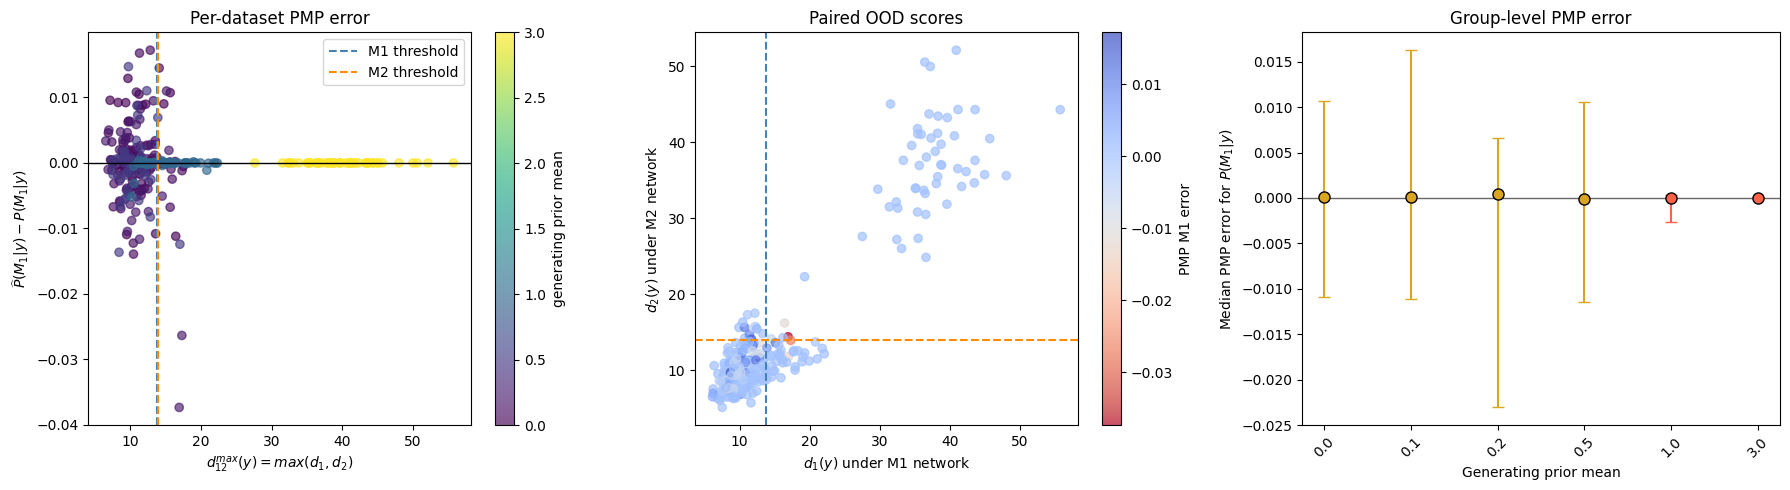

In [21]:
# Module 8: Plot paired OOD scores vs PMP error for P(M1 | y).
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sc = axes[0].scatter(bf12_df["d_max"], bf12_df["pmp_m1_error"], c=bf12_df["prior_mean"], cmap="viridis", alpha=0.65)
axes[0].axvline(ref1["threshold"], color="steelblue", ls="--", label="M1 threshold")
axes[0].axvline(ref2["threshold"], color="darkorange", ls="--", label="M2 threshold")
axes[0].axhline(0, color="black", lw=1)
axes[0].set_xlabel(r"$d_{12}^{max}(y)=max(d_1,d_2)$")
axes[0].set_ylabel(r"$\widehat{P}(M_1|y)-P(M_1|y)$")
axes[0].set_title("Per-dataset PMP error")
axes[0].legend()
fig.colorbar(sc, ax=axes[0], label="generating prior mean")

er = axes[1].scatter(bf12_df["d1"], bf12_df["d2"], c=bf12_df["pmp_m1_error"], cmap="coolwarm_r", alpha=0.70)
axes[1].axvline(ref1["threshold"], color="steelblue", ls="--")
axes[1].axhline(ref2["threshold"], color="darkorange", ls="--")
axes[1].set_xlabel(r"$d_1(y)$ under M1 network")
axes[1].set_ylabel(r"$d_2(y)$ under M2 network")
axes[1].set_title("Paired OOD scores")
fig.colorbar(er, ax=axes[1], label="PMP M1 error")

region_colors = []
for d in pmp12_summary["median_d_max"]:
    if d < min(ref1["median"], ref2["median"]):
        region_colors.append("royalblue")
    elif d <= max(ref1["threshold"], ref2["threshold"]):
        region_colors.append("goldenrod")
    else:
        region_colors.append("tomato")

x = np.arange(len(pmp12_summary))
axes[2].axhline(0, color="black", lw=1, alpha=0.6)
for i, row in pmp12_summary.iterrows():
    axes[2].errorbar(
        i,
        row["median_pmp_m1_error"],
        yerr=[
            [row["median_pmp_m1_error"] - row["q025_pmp_m1_error"]],
            [row["q975_pmp_m1_error"] - row["median_pmp_m1_error"]],
        ],
        fmt="o",
        ms=8,
        capsize=4,
        color=region_colors[i],
        markeredgecolor="black",
    )

axes[2].set_xticks(x)
axes[2].set_xticklabels([str(v) for v in pmp12_summary["prior_mean"]], rotation=45)
axes[2].set_xlabel("Generating prior mean")
axes[2].set_ylabel(r"Median PMP error for $P(M_1|y)$")
axes[2].set_title("Group-level PMP error")

plt.tight_layout()
plt.show()


In [22]:
prior_mean_errlogml = (
    bf12_df
    .groupby("prior_mean", sort=False)["pmp_m1_error"]
    .median()
    .reset_index()
)

prior_mean_errlogml.columns = ["prior_mean", "median_pmp_m1_error"]

print(prior_mean_errlogml.round(3))

   prior_mean  median_pmp_m1_error
0         0.0                  0.0
1         0.1                  0.0
2         0.2                  0.0
3         0.5                 -0.0
4         1.0                 -0.0
5         3.0                 -0.0
